In [ ]:
# Task 1: Iris Flower Classification

# Objective

The objective of this project is to train a machine learning classification
model to identify iris flower species based on their physical measurements.

# Technologies Used
- Python
- Pandas
- Scikit-learn
- Matplotlib
- Seaborn
- Jupyter Notebook

In [ ]:
# Import required libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [ ]:
# Load Iris dataset
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add target column
df["species"] = iris.target

# Convert numerical target to species names
df["species"] = df["species"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

# Display the dataset
df.head(150)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (150, 5)


In [ ]:
print("Null values:")
print(df.isnull().sum())

Null values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


In [ ]:
df.describe()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
print(df["species"].value_counts())

species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


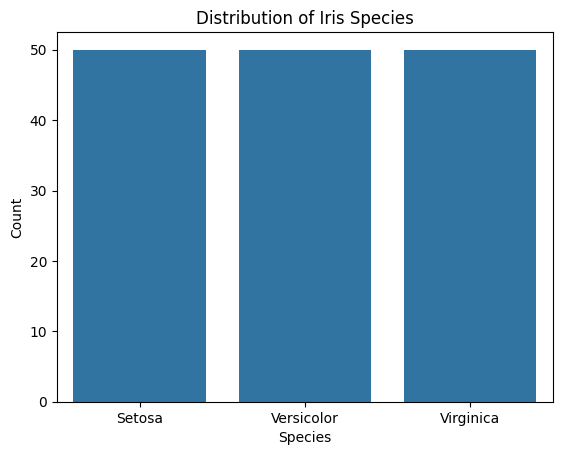

In [ ]:
sns.countplot(data=df, x="species")

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

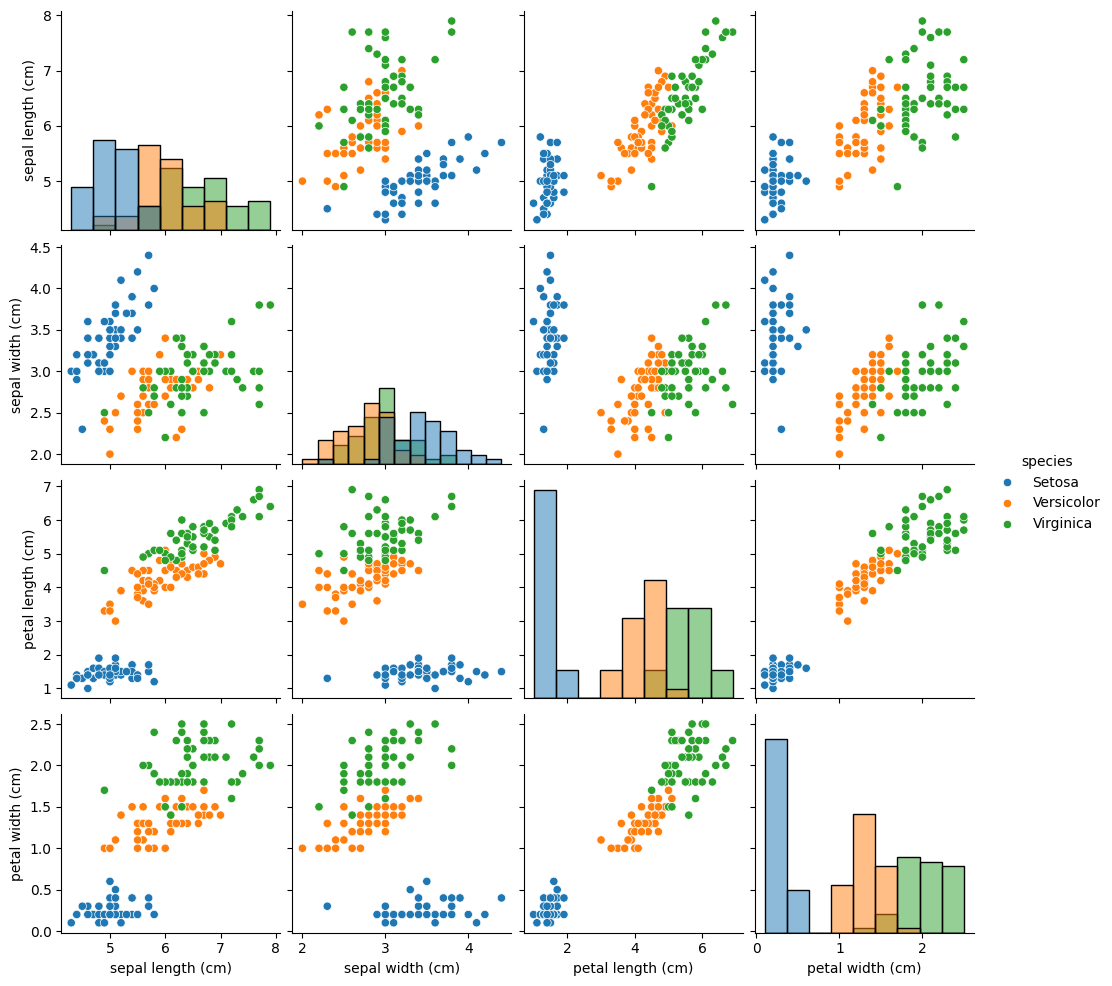

In [ ]:
sns.pairplot(
    df,
    hue="species",
    diag_kind="hist"
)

plt.show()

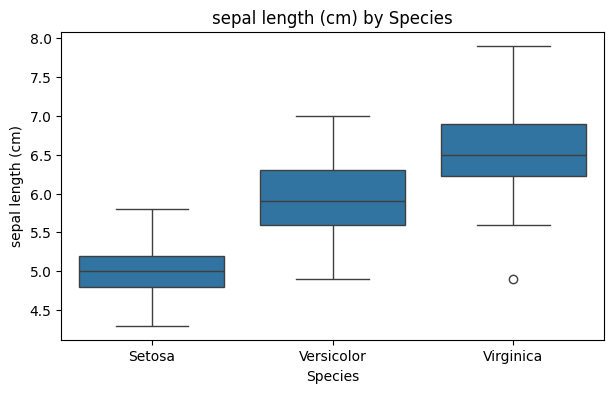

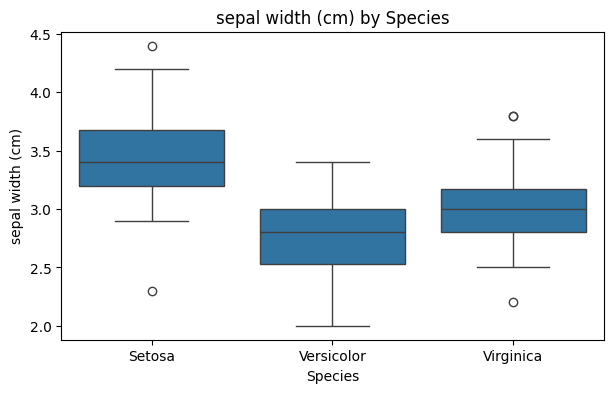

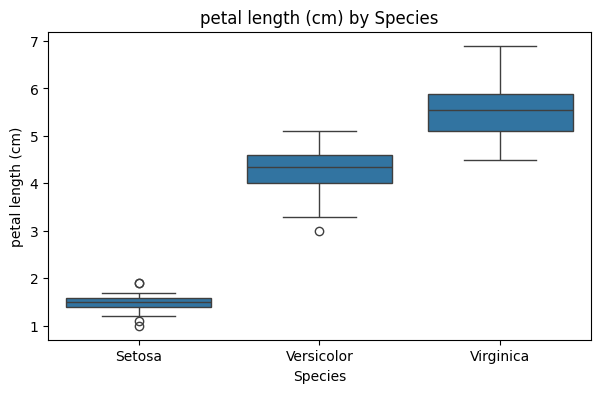

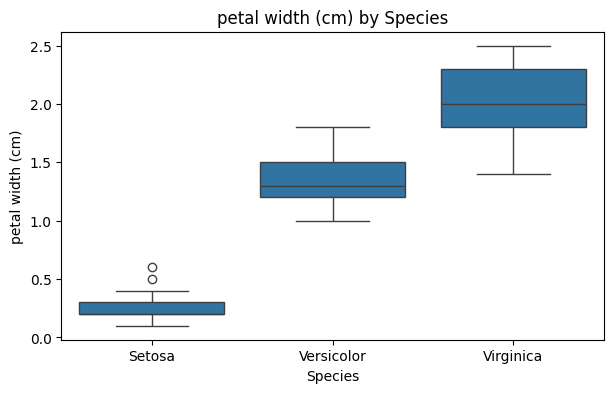

In [ ]:
features = iris.feature_names

for feature in features:
    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=df,
        x="species",
        y=feature
    )

    plt.title(f"{feature} by Species")
    plt.xlabel("Species")
    plt.ylabel(feature)
    plt.show()

In [ ]:
# Features
X = df[iris.feature_names]

# Target
y = iris.target

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Create model
logistic_model = LogisticRegression(max_iter=200)

# Train model
logistic_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = logistic_model.predict(X_test_scaled)

In [ ]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:",
      accuracy_lr)

Logistic Regression Accuracy: 0.9333333333333333


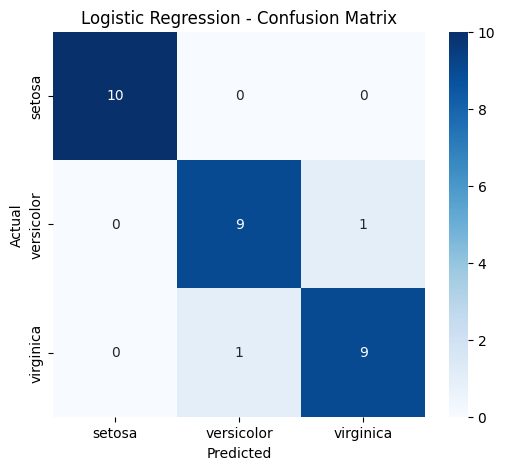

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
print("Logistic Regression Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=iris.target_names
    )
)

Logistic Regression Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [ ]:
# Create KNN model
knn_model = KNeighborsClassifier(n_neighbors=13)

# Train model
knn_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_knn = knn_model.predict(X_test_scaled)

In [ ]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", accuracy_knn)

KNN Accuracy: 0.9666666666666667


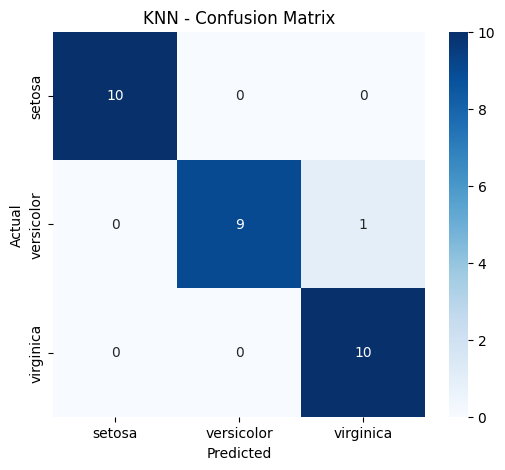

In [ ]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("KNN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
print("KNN Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_knn,
        target_names=iris.target_names
    )
)

KNN Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "K-Nearest Neighbours"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_knn
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.933333
1,K-Nearest Neighbours,0.966667


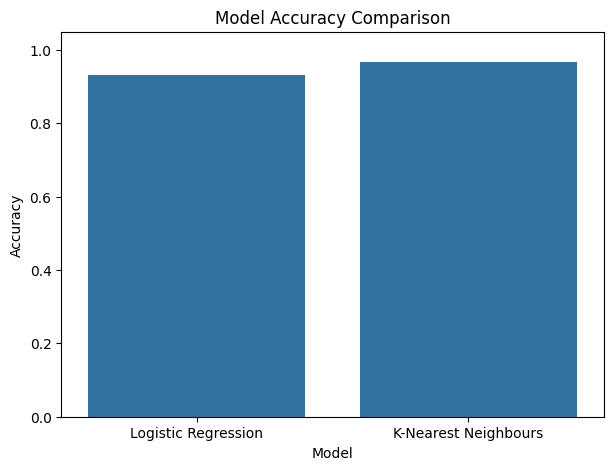

In [ ]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.xlabel("Model")

plt.show()

In [ ]:

best_model = results.loc[
    results["Accuracy"].idxmax()
]

print("Best Performing Model:",
      best_model["Model"])

print("Accuracy:",
      best_model["Accuracy"])

Best Performing Model: K-Nearest Neighbours
Accuracy: 0.9666666666666667


In [ ]:
# Conclusion

Two classification algorithms were trained and evaluated:
1. Logistic Regression
2. K-Nearest Neighbours (KNN)

The K-Nearest Neighbours model achieved an accuracy of 96% on the
test dataset, demonstrating excellent performance in classifying the
three Iris species.

Based on the model evaluation results, including accuracy, confusion
matrix, precision, recall, and F1-score, KNN was selected as the
best-performing model.

The exploratory data analysis showed that petal length and petal
width are the most discriminative features for distinguishing between
Setosa, Versicolor, and Virginica.

Overall, the results demonstrate that machine learning can effectively
classify Iris flowers based on their physical measurements, with the
KNN model achieving 96% classification accuracy.